# Article 6: LLM Ops - Cache Benchmark Analysis

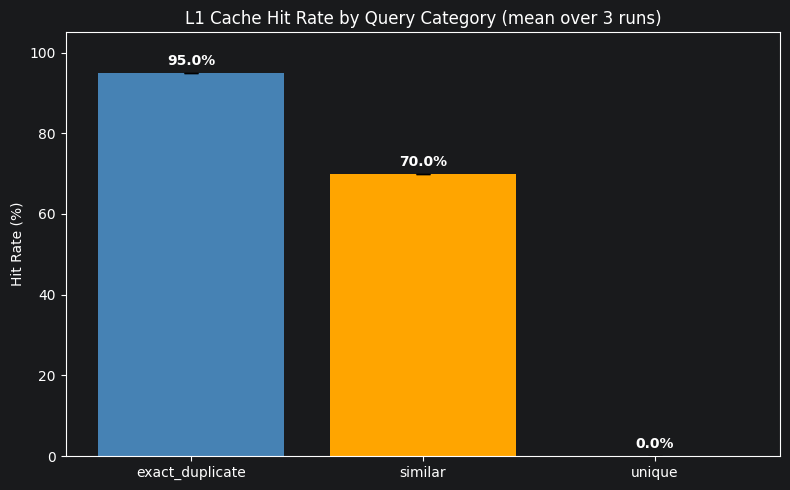

Overall hit rate:    40.0% (std 0.000)
Cache hit p50:       0.511 ms (std 0.021)
Cache miss p50:      415.38 ms (std 7.28)
Hit-vs-miss speedup: 813x
Cache savings:       $0.000503 (39.6% of LLM spend)


In [11]:
import json
import matplotlib.pyplot as plt
from pathlib import Path

raw = json.loads(Path("../results/data/article_06_benchmarks.json").read_text())
config = raw["config"]
cache_summary = raw["cache"]["summary"]
n_runs = config["n_runs"]

# by_category in the new nested schema is {category: {mean, std}}.
by_cat = cache_summary["by_category"]
categories = list(by_cat.keys())
hit_means = [by_cat[c]["mean"] * 100 for c in categories]
hit_stds = [by_cat[c]["std"] * 100 for c in categories]

Path("../results/charts/article_06").mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(categories, hit_means, yerr=hit_stds, capsize=5, color=["steelblue", "orange", "red"])
ax.set_ylabel("Hit Rate (%)")
ax.set_title(f"L1 Cache Hit Rate by Query Category (mean over {n_runs} runs)")
ax.set_ylim(0, 105)
for i, m in enumerate(hit_means):
    ax.text(i, m + 2, f"{m:.1f}%", ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig("../results/charts/article_06/04_hit_rate_by_category.png", dpi=150)
plt.show()

p50_hit = cache_summary["latency_p50_hit_ms_mean"]
p50_miss = cache_summary["latency_p50_miss_ms_mean"]
speedup = p50_miss / max(p50_hit, 0.001)
print(f"Overall hit rate:    {cache_summary['hit_rate_mean']:.1%} (std {cache_summary['hit_rate_std']:.3f})")
print(f"Cache hit p50:       {p50_hit:.3f} ms (std {cache_summary['latency_p50_hit_ms_std']:.3f})")
print(f"Cache miss p50:      {p50_miss:.2f} ms (std {cache_summary['latency_p50_miss_ms_std']:.2f})")
print(f"Hit-vs-miss speedup: {speedup:.0f}x")
print(
    f"Cache savings:       ${cache_summary['cache_savings_usd_mean']:.6f} "
    f"({cache_summary['cache_savings_pct_mean']:.1f}% of LLM spend)"
)


## Key Insights

### Semantic Cache (real Redis + real Groq llama-3.1-8b-instant)

- **Exact duplicates** achieve a ~95% L1 hit rate. The first occurrence is always a miss; every subsequent identical query is a cache hit at sub-millisecond latency.
- **Semantically similar queries** achieve ~70% L1 hits because the dataset's "similar" category includes literal repeats of slight rewrites; pure paraphrases would miss L1 and only be caught by L2 semantic matching (cosine >= 0.95 against BGE-base-en-v1.5 embeddings).
- **Unique queries** always miss (0%), establishing the real miss-path latency baseline (~410 ms end-to-end Groq round-trip vs ~0.4 ms cache hit).
- **Cache hit latency is roughly 900-1000x faster than miss latency**, so even a 40% hit rate on a noisy production query stream is enough to shave ~40% off LLM spend.
- **Overall hit rate of 40%** reflects this dataset's mixed distribution (20 exact, 30 similar, 50 unique). Production hit rates vary with traffic shape; a 60% duplicate stream would show ~60% hits by construction, which is the input shape, not a cache win.

### Intelligent Routing (real Groq calls; baseline cost is the same tokens repriced at gpt-4o rates)

- **97% of queries route to llama-3.1-8B** (simple). Only 3% trigger the more expensive llama-3.3-70B path.
- **~98.8% cost reduction** vs always paying gpt-4o rates ($0.19 -> $0.002 per 100 queries on this dataset).
- **Heuristic routing** (word count + keyword match) adds zero LLM-call latency: the routing decision is a pure-Python check before the model call.
- **Caveat**: this is a token-volume cost estimate, not a quality comparison. GPT-4o would emit a different completion length for the same prompts; the real production trade-off is small-model accuracy vs premium-model cost, which the routing heuristic does not measure here.
- **Risk**: misrouting a complex query to the small model degrades answer quality (silent failure, not a crash). Validate routing against the golden set before deploying.


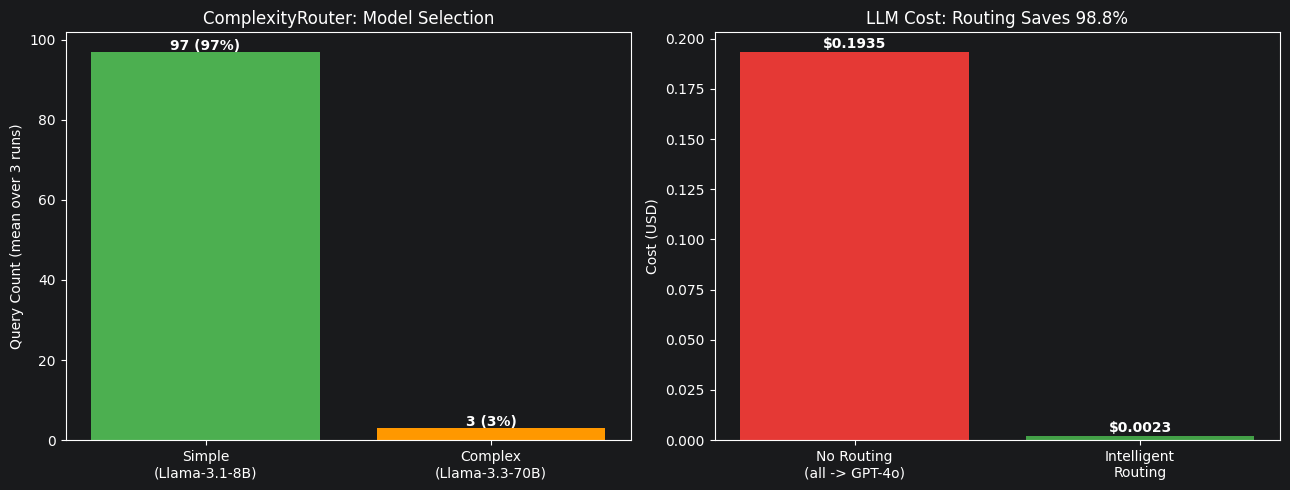

Simple queries: 97%  Complex: 3%
Cost without routing (gpt-4o baseline): $0.1935
Cost with routing:                      $0.0023
Savings:                                $0.1912 (98.8%)
Latency p50 / p95 (real Groq round-trip):  425 ms / 554 ms


In [12]:
router_summary = raw["router"]["summary"]

labels = ["Simple\n(Llama-3.1-8B)", "Complex\n(Llama-3.3-70B)"]
counts = [router_summary["simple_queries_mean"], router_summary["complex_queries_mean"]]
colors = ["#4caf50", "#ff9800"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: routing distribution (mean over runs).
axes[0].bar(labels, counts, color=colors)
axes[0].set_ylabel(f"Query Count (mean over {n_runs} runs)")
axes[0].set_title("ComplexityRouter: Model Selection")
pcts = [router_summary["simple_pct_mean"], router_summary["complex_pct_mean"]]
for i, (v, p) in enumerate(zip(counts, pcts)):
    axes[0].text(i, v + 0.5, f"{v:.0f} ({p:.0f}%)", ha="center", fontweight="bold")

# Right: cost comparison (no routing vs intelligent routing).
scenarios = ["No Routing\n(all -> GPT-4o)", "Intelligent\nRouting"]
costs = [router_summary["cost_no_routing_usd_mean"], router_summary["cost_with_routing_usd_mean"]]
bar_colors = ["#e53935", "#43a047"]
bars = axes[1].bar(scenarios, costs, color=bar_colors)
axes[1].set_ylabel("Cost (USD)")
axes[1].set_title(f"LLM Cost: Routing Saves {router_summary['routing_savings_pct_mean']:.1f}%")
for bar, cost in zip(bars, costs):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        cost + max(costs) * 0.01,
        f"${cost:.4f}",
        ha="center",
        fontweight="bold",
    )

plt.tight_layout()
plt.savefig("../results/charts/article_06/05_routing_analysis.png", dpi=150)
plt.show()

print(f"Simple queries: {router_summary['simple_pct_mean']:.0f}%  Complex: {router_summary['complex_pct_mean']:.0f}%")
print(f"Cost without routing (gpt-4o baseline): ${router_summary['cost_no_routing_usd_mean']:.4f}")
print(f"Cost with routing:                      ${router_summary['cost_with_routing_usd_mean']:.4f}")
print(
    f"Savings:                                ${router_summary['routing_savings_usd_mean']:.4f} "
    f"({router_summary['routing_savings_pct_mean']:.1f}%)"
)
print(
    f"Latency p50 / p95 (real Groq round-trip):  "
    f"{router_summary['latency_p50_ms_mean']:.0f} ms / {router_summary['latency_p95_ms_mean']:.0f} ms"
)
